
# Lab 6: FEM 1D

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

## Solución

Realmente no sabría hacer el código para resolver *cualquier* ecuación diferencial: se me ocurre, en general, resolver la ecuación de Poisson para cualquier función de densidad que se le ponga (al fin y al cabo sólo es integrarla).

Seguiré [la referencia](https://medium.com/@ariel.yaniv/finite-element-method-explained-how-to-solve-the-1d-poisson-equation-part-i-206b5bce1cfb) vista en clase.

In [ ]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

# Pongo la documentación porque la verdad la función es terrible,
# no dice qué hace cada input, es bastante arbitrario
def solve_poisson(a, b, ya, yb, f, N):
    """ Resuelve la ecuación de Poisson 1D con las condiciones de frontera 
        y(`a`) = `ya`, y(`b`) = `yb`, para la función de "densidad" `f`, 
        con `N` nodos
    """
    x = np.linspace(a, b, N)

    A = np.zeros((N, N)) # Matriz de rigidez
    c = np.zeros(N) # Vector de carga

    # Orgulloso de esta función, sirve para hacer las Galerkin tanto
    # en el medio como en los extremos
    def galerkin(x, xp, xi, xn):
        if x < xp or x > xn:
            return 0
        elif x <= xi:
            return (x - xp) / (xi - xp)
        elif x > xi:
            return (xn - x) / (xn - xi)

    for i in range(1, N - 1):
        A[i, i] = 1 / (x[i] - x[i-1]) + 1 / (x[i+1] - x[i])
        A[i, i - 1] = - 1 / (x[i] - x[i-1])
        A[i - 1, i] = - 1 / (x[i] - x[i-1])
        c[i] = integrate.quad(lambda z: galerkin(z, x[i-1], x[i], x[i+1]) * f(z), x[i-1], x[i+1])[0]

    # Primer y último nodo
    A[0, 0] = 1 / (x[1] - x[0])
    A[-1, -1] = 1 / (x[-1] - x[-2])
    A[-1, -2] = - 1 / (x[-1] - x[-2])
    A[-2, -1] = - 1 / (x[-1] - x[-2])
    c[0]  = integrate.quad(lambda z: galerkin(z, x[0], x[0], x[1]) * f(z), x[0], x[1])[0]
    c[-1] = integrate.quad(lambda z: galerkin(z, x[-2], x[-2], x[-1]) * f(z), x[-2], x[-1])[0]

    # Como las condiciones son de Dirichlet, la primera y última ecuación son redundantes
    # solo hace falta resolver un sistema (N-2)x(N-2)
    c[1] += -A[1,0] * ya
    c[-2] += -A[-2, -1] * yb

    # Solucionar el sistema
    y = np.zeros(N)
    y[1:N-1] = np.dot(np.linalg.inv(A[1:N-1, 1:N-1]), c[1:N-1])
    y[0]  = ya
    y[-1] = yb

    return x, y

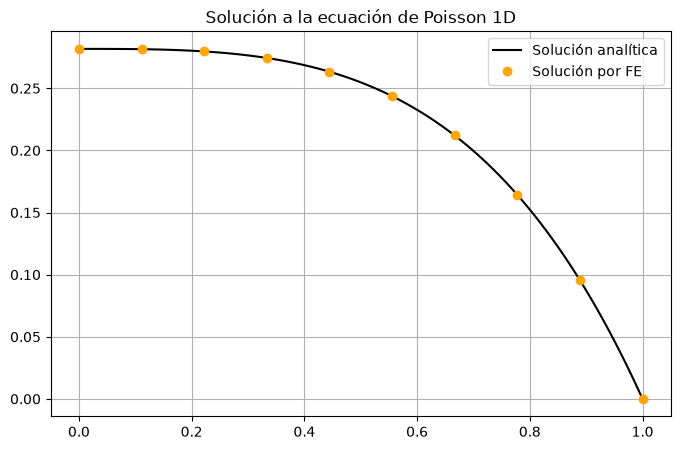

In [2]:
# Condiciones de frontera
a = 0
b = 1
y0 = 3 - np.e
yf = 0

N = 10

x, y = solve_poisson(a, b, y0, yf, lambda x: x*np.exp(x), N)

f_exact = lambda x: 1 - np.e - np.exp(x) * (x - 2) - x
x_exact = np.linspace(a, b, 100)

plt.figure(figsize=(8, 5))
plt.plot(x_exact, f_exact(x_exact), color="black", label="Solución analítica")
plt.plot(x, y, "o", color="orange", label="Solución por FE")
plt.title("Solución a la ecuación de Poisson 1D")
plt.legend()
plt.grid()
plt.show()

El error en general es alrededor del orden de $10^{-15}$ (calculando el error únicamente en los nodos). Para tener la versión "continua" de la solución únicamente habría que aumentar el `N` que se le pone a la función. En principio, el error máximo (en los nodos) no debería de variar según la cantidad de puntos utilizados.